In [1]:
%pip install pandas numpy scikit-learn matplotlib seaborn joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\samro\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [3]:
np.random.seed(42)

# Grupo A: Premium
altitud_A = np.random.normal(1500, 80, 180)
humedad_A = np.random.normal(65, 4, 180)
temp_A = np.random.normal(17, 1.2, 180)
rendimiento_A = np.random.normal(11, 1.2, 180)
costo_kilo_A = np.random.normal(3.8, 0.4, 180)
puntaje_sca_A = np.random.normal(85.5, 1.5, 180)

# Grupo B: Masivo
altitud_B = np.random.normal(950, 90, 200)
humedad_B = np.random.normal(72, 3.5, 200)
temp_B = np.random.normal(22, 1.5, 200)
rendimiento_B = np.random.normal(16, 1.8, 200)
costo_kilo_B = np.random.normal(2.2, 0.3, 200)
puntaje_sca_B = np.random.normal(81.0, 1.2, 200)

# Grupo C: Crítico
altitud_C = np.random.normal(550, 70, 120)
humedad_C = np.random.normal(48, 5, 120)
temp_C = np.random.normal(28, 2.0, 120)
rendimiento_C = np.random.normal(6.5, 1.5, 120)
costo_kilo_C = np.random.normal(4.5, 0.6, 120)
puntaje_sca_C = np.random.normal(76.0, 2.0, 120)

df = pd.DataFrame({
    'altitud': np.concatenate([altitud_A, altitud_B, altitud_C]),
    'humedad': np.concatenate([humedad_A, humedad_B, humedad_C]),
    'temperatura': np.concatenate([temp_A, temp_B, temp_C]),
    'rendimiento': np.concatenate([rendimiento_A, rendimiento_B, rendimiento_C]),
    'costo_kilo': np.concatenate([costo_kilo_A, costo_kilo_B, costo_kilo_C]),
    'puntaje_sca': np.concatenate([puntaje_sca_A, puntaje_sca_B, puntaje_sca_C])
})

df.head()

,altitud,humedad,temperatura,rendimiento,costo_kilo,puntaje_sca
0,1539.737132,67.502669,17.623216,12.002831,3.923121,86.053010
1,1488.938856,61.571370,18.839287,9.644352,3.115933,84.909992
2,1551.815083,60.716430,16.869488,11.635765,3.260726,85.543117
3,1621.842389,66.929890,17.482054,12.729882,4.097306,87.417678
4,1481.267730,64.106149,17.828173,8.034027,3.868346,85.786649


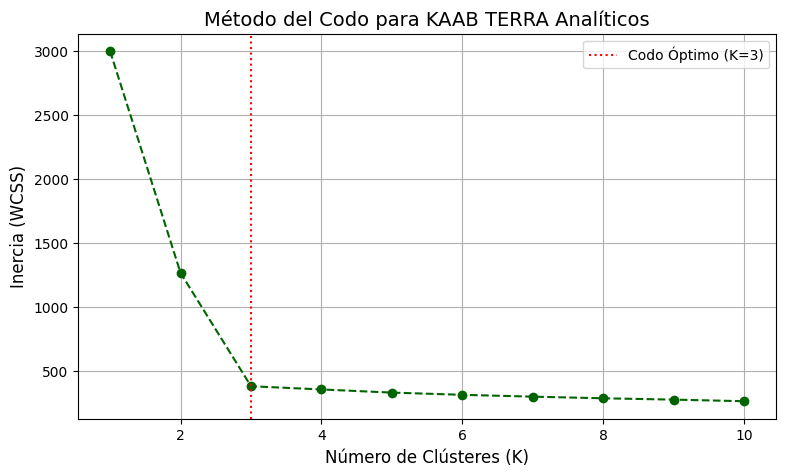

In [4]:
features = ['altitud', 'humedad', 'temperatura', 'rendimiento', 'costo_kilo', 'puntaje_sca']
X = df[features]

scaler_temp = StandardScaler()
X_scaled = scaler_temp.fit_transform(X)

wcss = [] 
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='darkgreen')
plt.title('Método del Codo para KAAB TERRA Analíticos', fontsize=14)
plt.xlabel('Número de Clústeres (K)', fontsize=12)
plt.ylabel('Inercia (WCSS)', fontsize=12)
plt.grid(True)
plt.axvline(x=3, color='red', linestyle=':', label='Codo Óptimo (K=3)')
plt.legend()
plt.show()

In [5]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10))
])

pipeline.fit(X)
df['cluster'] = pipeline.named_steps['kmeans'].labels_

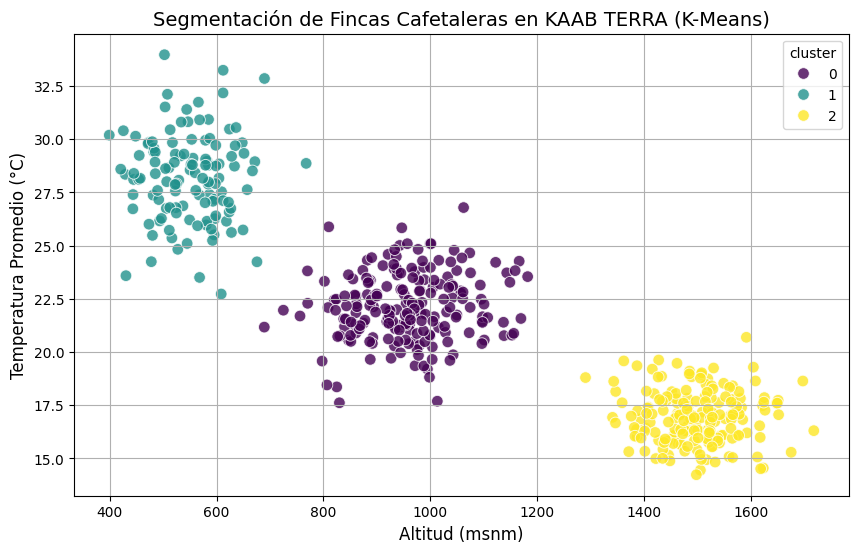


--- Características promedio por cada Clúster Encontrado ---
         altitud  humedad  temperatura  rendimiento  costo_kilo  puntaje_sca
cluster                                                                     
0         958.44    72.23        22.12        16.00        2.21        80.95
1         550.35    48.30        28.19         6.67        4.44        76.01
2        1498.23    65.10        16.94        11.01        3.85        85.63


In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='altitud', 
    y='temperatura', 
    hue='cluster', 
    palette='viridis', 
    s=70, 
    alpha=0.8
)
plt.title('Segmentación de Fincas Cafetaleras en KAAB TERRA (K-Means)', fontsize=14)
plt.xlabel('Altitud (msnm)', fontsize=12)
plt.ylabel('Temperatura Promedio (°C)', fontsize=12)
plt.grid(True)
plt.show()

print("\n--- Características promedio por cada Clúster Encontrado ---")
print(df.groupby('cluster').mean().round(2))

In [7]:
os.makedirs('../models_saved', exist_ok=True)
joblib.dump(pipeline, '../models_saved/pipeline_kaab_terra_clustering.joblib')
print("¡Pipeline guardado con éxito para la API!")

¡Pipeline guardado con éxito para la API!
